## 1. Load & Explore the Dataset 

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib

In [65]:
df = pd.read_csv('FACT_Shipments.csv')
df.head(5)

,Shipment_ID,Customer_ID,Origin_ServiceCenter_ID,Destination_ServiceCenter_ID,Driver_ID,Equipment_ID,Pickup_Date,Delivery_Date,Promised_Delivery_Date,Month,Quarter,Year,Service_Type,Origin_State_Full,Destination_State_Full,Weight_lbs,Pieces,Pallets,Freight_Class,Transit_Days_Actual,Transit_Days_Promised,On_Time,Base_Rate_USD,Fuel_Surcharge_USD,Accessorial_Charges_USD,Total_Revenue_USD,Total_Cost_USD,Gross_Margin_USD,Gross_Margin_Pct,Claim_Filed,Claim_Reason,Claim_Amount_USD,Miles,Revenue_Per_Hundredweight,Revenue_Per_Mile
0,PRO1000011,CUST0263,SC027,SC017,DRV0140,TRK0021,"Monday, February 13, 2023","Thursday, February 16, 2023","Thursday, February 16, 2023",February,1,2023,Retail,Missouri,Oklahoma,6442.90,2,1,175.00,3.00,3,True,$827.80,$168.36,$0,$996.16,$655.20,$340.96,34.23,False,No Claim,$0,1182,$15.46,1.01
1,PRO1000026,CUST0035,SC012,SC002,DRV0056,TRK0106,"Thursday, October 10, 2024","Sunday, October 13, 2024","Sunday, October 13, 2024",October,4,2024,Time-Critical,Tennessee,Ohio,447.60,1,1,125.00,3.00,3,True,$82.84,$18.71,$0,$101.55,$80.68,$20.87,20.55,False,No Claim,$0,1285,$22.69,0.05
2,PRO1000045,CUST0113,SC025,SC009,DRV0185,TRK0066,"Tuesday, February 20, 2024","Friday, February 23, 2024","Friday, February 23, 2024",February,1,2024,Time-Critical,Missouri,Utah,13245.90,7,1,60.00,3.00,3,True,"$2,615.02",$657.88,$0,"$3,272.90","$2,712.22",$560.68,17.13,False,No Claim,$0,2000,$24.71,5.91
3,PRO1000063,CUST0235,SC014,SC023,DRV0047,TRK0113,"Tuesday, July 11, 2023","Friday, July 14, 2023","Friday, July 14, 2023",July,3,2023,Time-Critical,Washington,Michigan,2982.00,4,1,100.00,3.00,3,True,$978.03,$238.56,$0,"$1,216.60",$952.91,$263.69,21.67,False,No Claim,$0,1499,$40.80,0.62
4,PRO1000165,CUST0126,SC021,SC029,DRV0075,TRK0034,"Monday, January 15, 2024","Thursday, January 18, 2024","Thursday, January 18, 2024",January,1,2024,Time-Critical,Ohio,Massachusetts,445.70,4,1,92.50,3.00,3,True,$44.88,$8.65,$0,$53.52,$30.14,$23.38,43.68,False,No Claim,$0,1679,$12.01,0.03


In [66]:
def explore_data(data):
    print(f"Shape: {data.shape}")
    print("\nData Types:\n", data.dtypes.value_counts())
    print("\nMissing Values:\n", data.isnull().sum().sum())
    return data.describe()

explore_data(df)

Shape: (5000, 35)

Data Types:
 object     22
int64       6
float64     5
bool        2
Name: count, dtype: int64

Missing Values:
 468


,Quarter,Year,Weight_lbs,Pieces,Pallets,Freight_Class,Transit_Days_Actual,Transit_Days_Promised,Gross_Margin_Pct,Miles,Revenue_Per_Mile
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,4766.00,5000.00,5000.00,5000.00,5000.00
mean,2.51,2023.52,10217.18,24.11,5.71,157.74,3.60,3.87,30.19,1270.89,4.43
std,1.11,0.50,5766.82,13.93,3.41,122.23,1.37,1.44,8.68,707.70,8.86
min,1.00,2023.00,151.50,1.00,1.00,50.00,1.00,1.00,15.01,50.00,0.01
25%,2.00,2023.00,5246.45,12.00,3.00,70.00,3.00,3.00,22.81,647.00,0.97
50%,2.00,2024.00,10272.65,24.00,6.00,100.00,3.00,4.00,30.35,1273.50,2.01
75%,4.00,2024.00,15227.98,36.00,9.00,200.00,4.00,5.00,37.77,1886.00,4.18
max,4.00,2024.00,19993.10,48.00,12.00,500.00,7.00,8.00,44.99,2500.00,139.07


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Shipment_ID                   5000 non-null   object 
 1   Customer_ID                   5000 non-null   object 
 2   Origin_ServiceCenter_ID       5000 non-null   object 
 3   Destination_ServiceCenter_ID  5000 non-null   object 
 4   Driver_ID                     5000 non-null   object 
 5   Equipment_ID                  5000 non-null   object 
 6   Pickup_Date                   5000 non-null   object 
 7   Delivery_Date                 4766 non-null   object 
 8   Promised_Delivery_Date        5000 non-null   object 
 9   Month                         5000 non-null   object 
 10  Quarter                       5000 non-null   int64  
 11  Year                          5000 non-null   int64  
 12  Service_Type                  5000 non-null   object 
 13  Ori

In [68]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Shipment_ID,5000,5000,PRO1000011,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,5000,300,CUST0010,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Origin_ServiceCenter_ID,5000,30,SC010,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination_ServiceCenter_ID,5000,30,SC012,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver_ID,5000,200,DRV0008,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Equipment_ID,5000,150,TRK0117,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup_Date,5000,730,"Thursday, May 2, 2024",17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_Date,4766,733,"Thursday, March 14, 2024",15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promised_Delivery_Date,5000,733,"Tuesday, July 2, 2024",15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,5000,12,May,467,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing.to_frame('Missing Count').assign(Pct=lambda x: (x['Missing Count']/len(df)*100).round(2)))


Columns with missing values:
                     Missing Count  Pct
Delivery_Date                  234 4.68
Transit_Days_Actual            234 4.68


In [70]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


# 2. Exploratory Data Analysis (EDA)

In [71]:
# ── Helper: clean dollar-string columns ──
dollar_cols = [
    'Base_Rate_USD', 'Fuel_Surcharge_USD', 'Accessorial_Charges_USD',
    'Total_Revenue_USD', 'Total_Cost_USD', 'Gross_Margin_USD',
    'Claim_Amount_USD', 'Revenue_Per_Hundredweight'
]

def parse_dollar(series):
    """Strip '$' and ',' then cast to float."""
    return series.astype(str).str.replace(r'[\$,]', '', regex=True).str.strip().astype(float)

df_clean = df.copy()
for col in dollar_cols:
    df_clean[col] = parse_dollar(df_clean[col])

print('Dollar columns converted. Sample:')
df_clean[dollar_cols].head(3)


Dollar columns converted. Sample:


,Base_Rate_USD,Fuel_Surcharge_USD,Accessorial_Charges_USD,Total_Revenue_USD,Total_Cost_USD,Gross_Margin_USD,Claim_Amount_USD,Revenue_Per_Hundredweight
0,827.80,168.36,0.00,996.16,655.20,340.96,0.00,15.46
1,82.84,18.71,0.00,101.55,80.68,20.87,0.00,22.69
2,2615.02,657.88,0.00,3272.90,2712.22,560.68,0.00,24.71


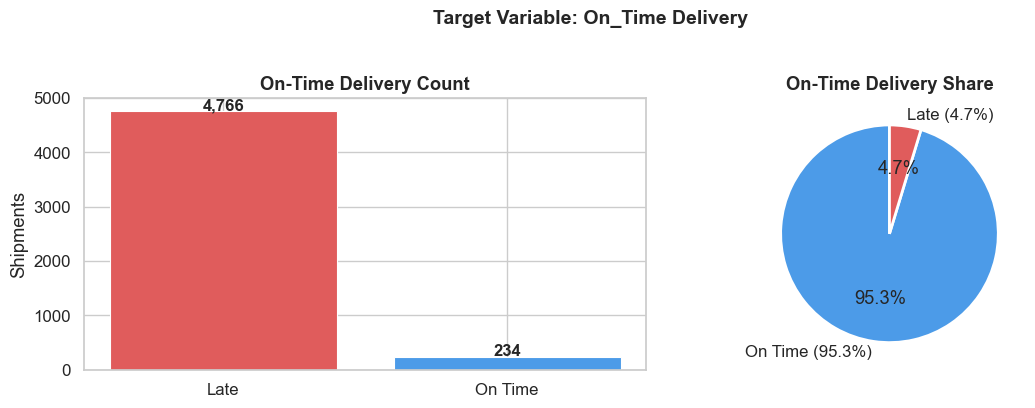

⚠️  Note: Class imbalance detected — Late shipments are only ~4.7%. We will address this.


In [72]:
# ── Target variable distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean['On_Time'].value_counts()
axes[0].bar(['Late', 'On Time'], counts.values, color=['#e05c5c','#4c9be8'], edgecolor='white', linewidth=0.8)
axes[0].set_title('On-Time Delivery Count', fontweight='bold')
axes[0].set_ylabel('Shipments')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

axes[1].pie(counts.values, labels=['On Time (95.3%)', 'Late (4.7%)'],
            colors=['#4c9be8','#e05c5c'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('On-Time Delivery Share', fontweight='bold')

plt.suptitle('Target Variable: On_Time Delivery', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  Note: Class imbalance detected — Late shipments are only ~4.7%. We will address this.')


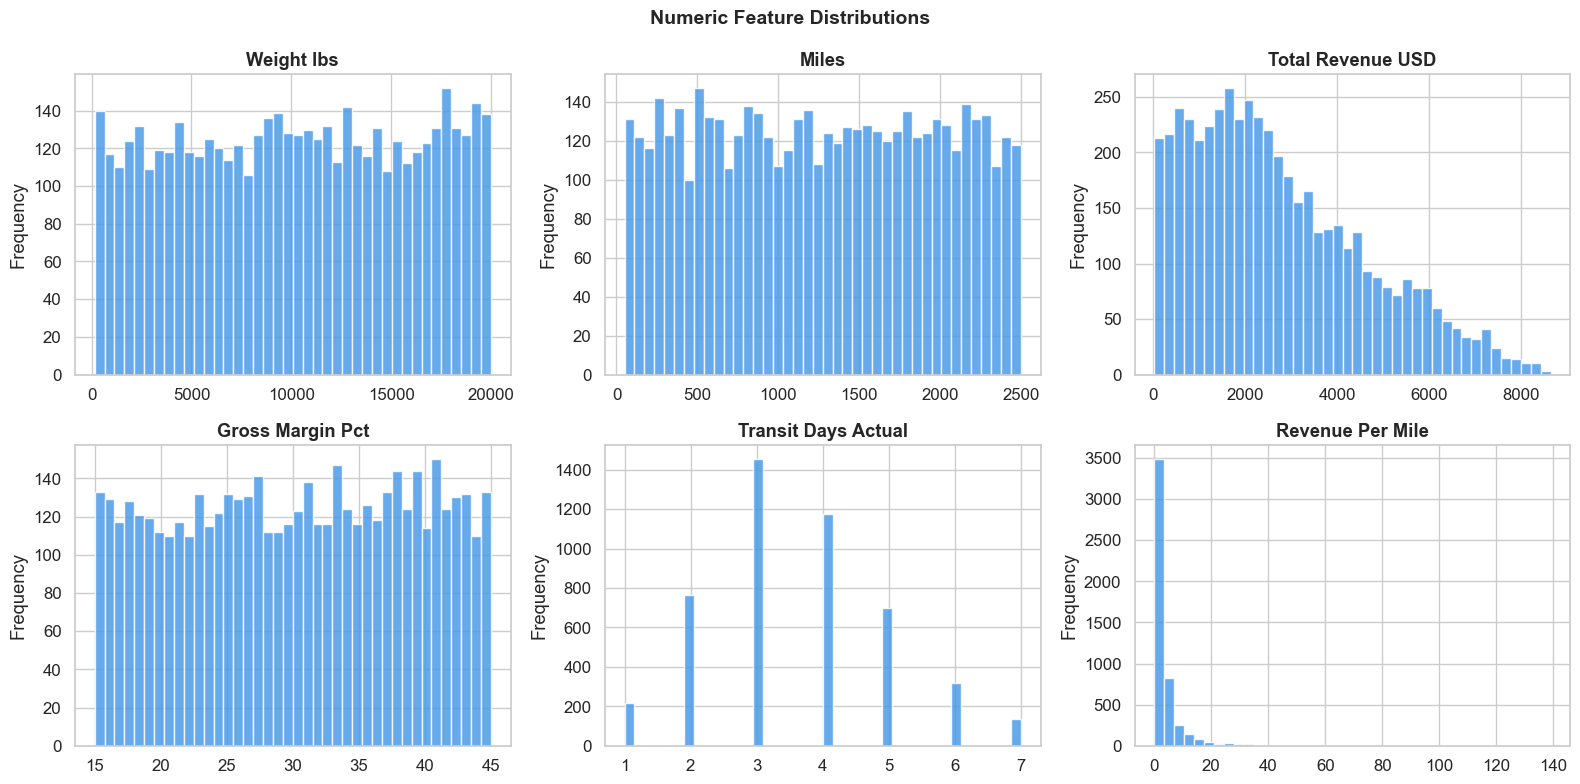

In [73]:
# ── Numeric distributions ──
num_cols = ['Weight_lbs', 'Miles', 'Total_Revenue_USD', 'Gross_Margin_Pct',
            'Transit_Days_Actual', 'Revenue_Per_Mile']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df_clean[col].dropna(), bins=40, color='#4c9be8', edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


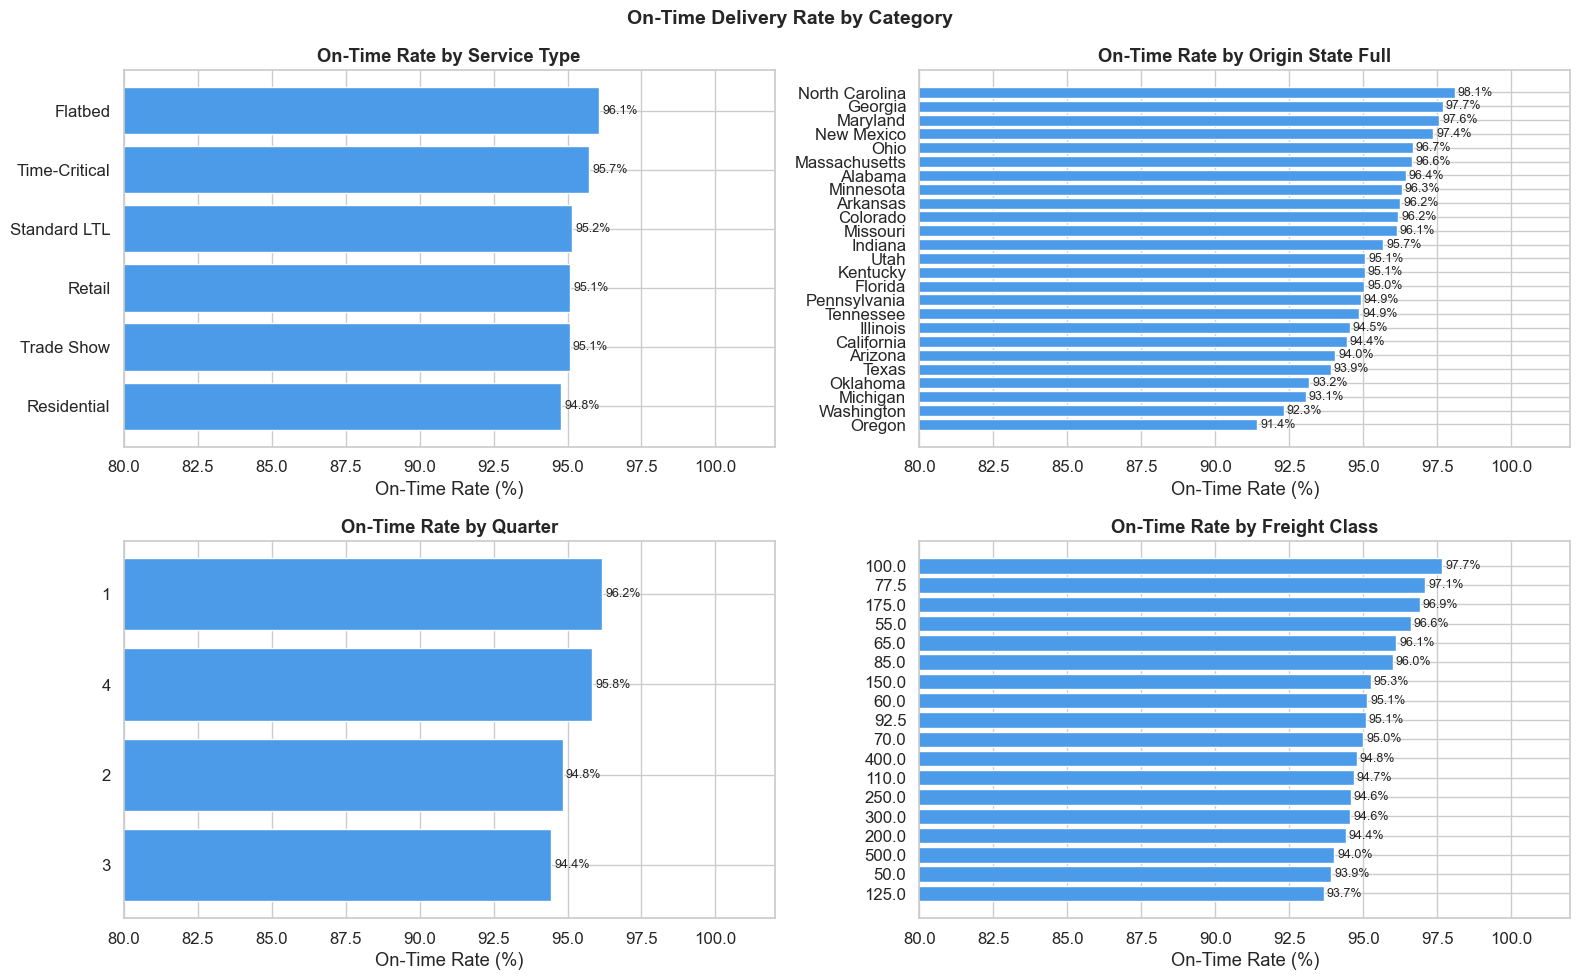

In [74]:
# ── Categorical features vs On_Time ──
cat_cols = ['Service_Type', 'Origin_State_Full', 'Quarter', 'Freight_Class']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    ontime_rate = df_clean.groupby(col)['On_Time'].mean().sort_values()
    bars = ax.barh(ontime_rate.index.astype(str), ontime_rate.values * 100,
                   color='#4c9be8', edgecolor='white')
    ax.set_xlabel('On-Time Rate (%)')
    ax.set_title(f'On-Time Rate by {col.replace("_", " ")}', fontweight='bold')
    ax.set_xlim(80, 102)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.1, bar.get_y() + bar.get_height()/2,
                f'{w:.1f}%', va='center', fontsize=9)

plt.suptitle('On-Time Delivery Rate by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_categorical.png', dpi=150, bbox_inches='tight')
plt.show()


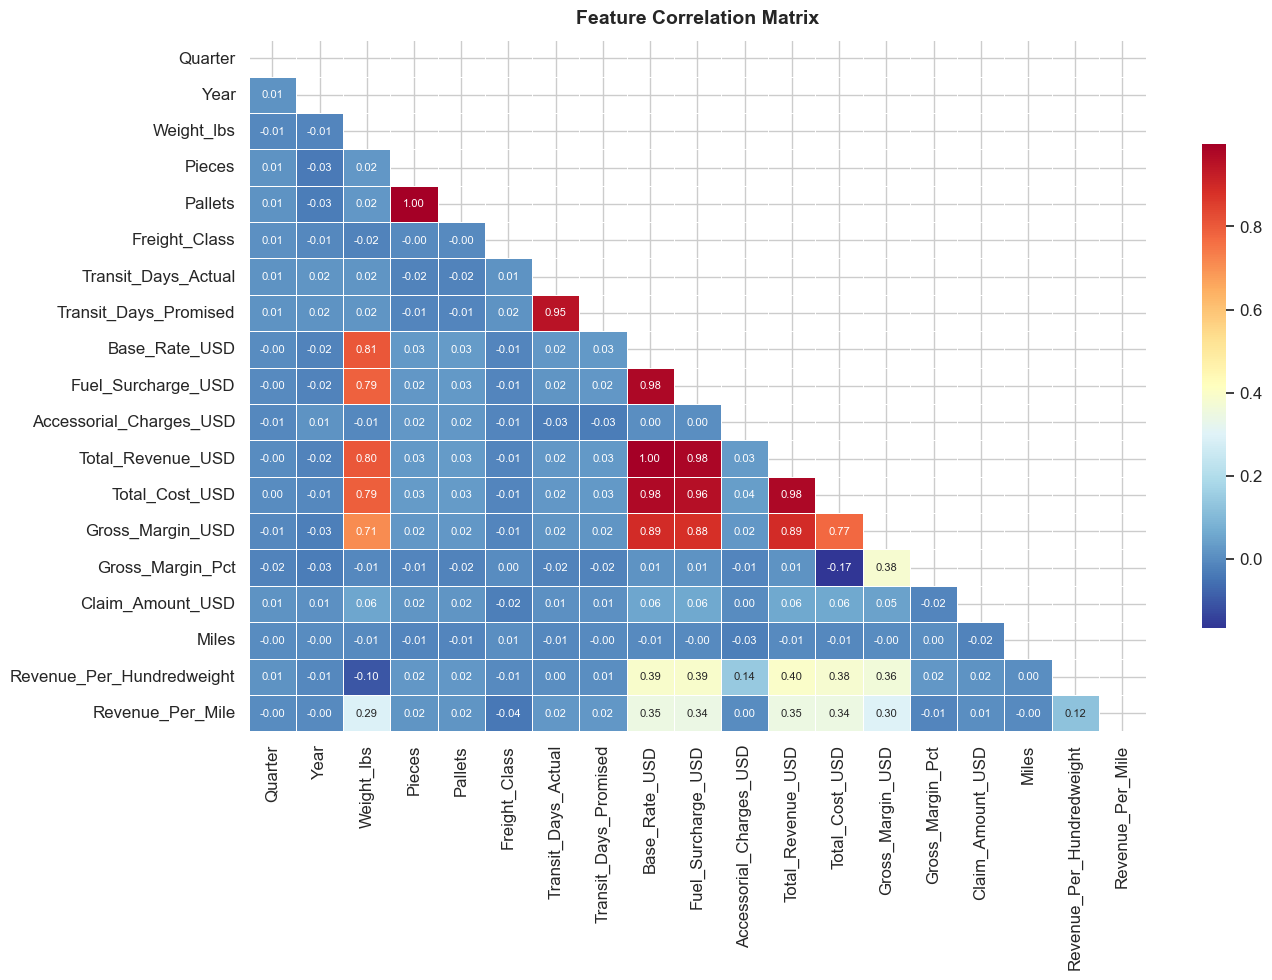

In [75]:
# ── Correlation heatmap ──
num_df = df_clean.select_dtypes(include='number')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            linewidths=0.5, ax=ax, annot_kws={'size':8},
            cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


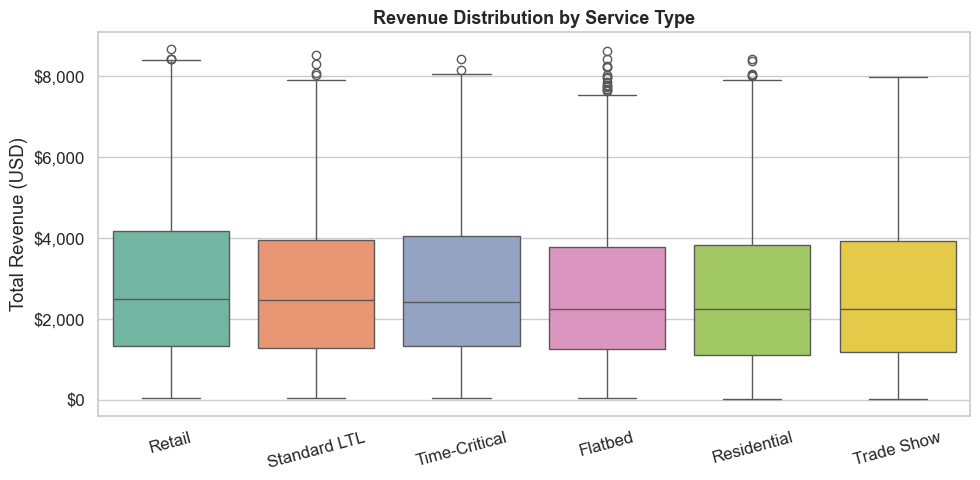

In [76]:
# ── Revenue by Service Type ──
fig, ax = plt.subplots(figsize=(10, 5))
order = df_clean.groupby('Service_Type')['Total_Revenue_USD'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='Service_Type', y='Total_Revenue_USD',
            order=order, palette='Set2', ax=ax)
ax.set_title('Revenue Distribution by Service Type', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot_revenue_by_service.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

In [77]:
# ── Step 1: Drop ID / date / leakage columns ─────────────────────────────
drop_cols = [
    'Shipment_ID', 'Customer_ID', 'Driver_ID', 'Equipment_ID',
    'Origin_ServiceCenter_ID', 'Destination_ServiceCenter_ID',
    'Pickup_Date', 'Delivery_Date', 'Promised_Delivery_Date',
    'Month',
    'Claim_Reason',
    'Claim_Amount_USD',
]

df_proc = df_clean.drop(columns=drop_cols)
print(f'Remaining columns ({len(df_proc.columns)}): {df_proc.columns.tolist()}')


Remaining columns (23): ['Quarter', 'Year', 'Service_Type', 'Origin_State_Full', 'Destination_State_Full', 'Weight_lbs', 'Pieces', 'Pallets', 'Freight_Class', 'Transit_Days_Actual', 'Transit_Days_Promised', 'On_Time', 'Base_Rate_USD', 'Fuel_Surcharge_USD', 'Accessorial_Charges_USD', 'Total_Revenue_USD', 'Total_Cost_USD', 'Gross_Margin_USD', 'Gross_Margin_Pct', 'Claim_Filed', 'Miles', 'Revenue_Per_Hundredweight', 'Revenue_Per_Mile']


In [78]:
# ── Step 2: Feature Engineering ──
# Transit delay: how many extra days beyond promised
df_proc['Transit_Delay_Days'] = (
    df_proc['Transit_Days_Actual'] - df_proc['Transit_Days_Promised']
).clip(lower=0)

# Revenue efficiency
df_proc['Cost_Ratio'] = df_proc['Total_Cost_USD'] / (df_proc['Total_Revenue_USD'] + 1e-9)

# Weight density
df_proc['Weight_Per_Piece'] = df_proc['Weight_lbs'] / (df_proc['Pieces'] + 1e-9)

print('✅ Feature engineering complete. New features: Transit_Delay_Days, Cost_Ratio, Weight_Per_Piece')


✅ Feature engineering complete. New features: Transit_Delay_Days, Cost_Ratio, Weight_Per_Piece


In [79]:
# ── Step 3: Impute missing values ──
median_transit = df_proc.groupby('Service_Type')['Transit_Days_Actual'].transform('median')
df_proc['Transit_Days_Actual'] = df_proc['Transit_Days_Actual'].fillna(median_transit)

df_proc['Transit_Delay_Days'] = (
    df_proc['Transit_Days_Actual'] - df_proc['Transit_Days_Promised']
).clip(lower=0)

print(f'Missing after imputation: {df_proc.isnull().sum().sum()}')


Missing after imputation: 0


In [80]:
# ── Step 4: Outlier treatment (IQR capping) ───────────────────────────────
outlier_cols = ['Weight_lbs', 'Miles', 'Total_Revenue_USD', 'Gross_Margin_USD', 'Claim_Filed']
outlier_cols = ['Weight_lbs', 'Miles', 'Total_Revenue_USD', 'Gross_Margin_USD']

def cap_outliers_iqr(df, cols, factor=3.0):
    """Cap extreme values at Q1 - factor*IQR and Q3 + factor*IQR."""
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'  {col}: {n_outliers} outliers capped')
    return df

print('Outlier capping (IQR × 3):')
df_proc = cap_outliers_iqr(df_proc, outlier_cols)


Outlier capping (IQR × 3):
  Weight_lbs: 0 outliers capped
  Miles: 0 outliers capped
  Total_Revenue_USD: 0 outliers capped
  Gross_Margin_USD: 1 outliers capped


In [81]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Settings ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42

In [82]:
# ── Step 5: Encode categorical variables ──
# Low-cardinality: One-Hot Encoding
ohe_cols = ['Service_Type', 'Quarter']

# High-cardinality (states): Label Encoding to avoid explosion
le_cols = ['Origin_State_Full', 'Destination_State_Full']

# Boolean columns -> int
df_proc['On_Time'] = df_proc['On_Time'].astype(int)
df_proc['Claim_Filed'] = df_proc['Claim_Filed'].astype(int)

# OHE
df_proc = pd.get_dummies(df_proc, columns=ohe_cols, drop_first=True)

# Label Encoding
le = LabelEncoder()
for col in le_cols:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

print(f'After encoding, shape: {df_proc.shape}')
df_proc.head(3)


After encoding, shape: (5000, 32)


,Year,Origin_State_Full,Destination_State_Full,Weight_lbs,Pieces,Pallets,Freight_Class,Transit_Days_Actual,Transit_Days_Promised,On_Time,Base_Rate_USD,Fuel_Surcharge_USD,Accessorial_Charges_USD,Total_Revenue_USD,Total_Cost_USD,Gross_Margin_USD,Gross_Margin_Pct,Claim_Filed,Miles,Revenue_Per_Hundredweight,Revenue_Per_Mile,Transit_Delay_Days,Cost_Ratio,Weight_Per_Piece,Service_Type_Residential,Service_Type_Retail,Service_Type_Standard LTL,Service_Type_Time-Critical,Service_Type_Trade Show,Quarter_2,Quarter_3,Quarter_4
0,2023,14,18,6442.90,2,1,175.00,3.00,3,1,827.80,168.36,0.00,996.16,655.20,340.96,34.23,0,1182,15.46,1.01,0.00,0.66,3221.45,False,True,False,False,False,False,False,False
1,2024,21,17,447.60,1,1,125.00,3.00,3,1,82.84,18.71,0.00,101.55,80.68,20.87,20.55,0,1285,22.69,0.05,0.00,0.79,447.60,False,False,False,True,False,False,False,True
2,2024,14,23,13245.90,7,1,60.00,3.00,3,1,2615.02,657.88,0.00,3272.90,2712.22,560.68,17.13,0,2000,24.71,5.91,0.00,0.83,1892.27,False,False,False,True,False,False,False,False


In [83]:
# ── Define X and y ──
TARGET = 'On_Time'

# Drop columns that would constitute target leakage
X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]

print(f'Features: {X.shape[1]}')
print(f'Samples : {X.shape[0]:,}')
print(f'Target distribution:\n{y.value_counts().rename({0:"Late",1:"On Time"})}')


Features: 31
Samples : 5,000
Target distribution:
On_Time
On Time    4766
Late        234
Name: count, dtype: int64


In [84]:
# ── Train / Test split (stratified to preserve class ratio) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Train on-time rate: {y_train.mean():.3f}  |  Test on-time rate: {y_test.mean():.3f}')


Train: 4,000 rows  |  Test: 1,000 rows
Train on-time rate: 0.953  |  Test on-time rate: 0.953


In [85]:
# ── Scale numeric features ──
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print('✅ Scaling complete.')


✅ Scaling complete.


# 3. Machine Learning Model

In [86]:
# ── Threshold Tuning (catches more Late shipments) ──
y_proba = gb_fitted.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_proba >= 0.3).astype(int)

print("Tuned threshold (0.3) results:")
print(classification_report(y_test, y_pred_tuned, target_names=['Late','On Time']))

Tuned threshold (0.3) results:
              precision    recall  f1-score   support

        Late       1.00      0.38      0.55        47
     On Time       0.97      1.00      0.99       953

    accuracy                           0.97      1000
   macro avg       0.99      0.69      0.77      1000
weighted avg       0.97      0.97      0.96      1000



In [87]:
# ── Evaluation helper ──
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, predict, and return a metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    metrics = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1 (Late)' : round(f1_score(y_te, y_pred, pos_label=0, zero_division=0), 4),
    }
    print(f'\n── {name} ──')
    print(classification_report(y_te, y_pred, target_names=['Late','On Time']))
    return metrics, model, y_pred


In [88]:
# ── Model 1: Logistic Regression ──
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_metrics, lr_fitted, lr_preds = evaluate_model(
    'Logistic Regression', lr, X_train_sc, y_train, X_test_sc, y_test
)


── Logistic Regression ──
              precision    recall  f1-score   support

        Late       0.18      0.64      0.28        47
     On Time       0.98      0.85      0.91       953

    accuracy                           0.84      1000
   macro avg       0.58      0.75      0.59      1000
weighted avg       0.94      0.84      0.88      1000



In [89]:
# ── Model 2: Random Forest ──
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_metrics, rf_fitted, rf_preds = evaluate_model(
    'Random Forest', rf, X_train, y_train, X_test, y_test
)



── Random Forest ──
              precision    recall  f1-score   support

        Late       1.00      0.34      0.51        47
     On Time       0.97      1.00      0.98       953

    accuracy                           0.97      1000
   macro avg       0.98      0.67      0.75      1000
weighted avg       0.97      0.97      0.96      1000



In [90]:
# ── Model 3: Gradient Boosting ──
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    random_state=RANDOM_STATE
)
gb_metrics, gb_fitted, gb_preds = evaluate_model(
    'Gradient Boosting', gb, X_train, y_train, X_test, y_test
)


── Gradient Boosting ──
              precision    recall  f1-score   support

        Late       1.00      0.51      0.68        47
     On Time       0.98      1.00      0.99       953

    accuracy                           0.98      1000
   macro avg       0.99      0.76      0.83      1000
weighted avg       0.98      0.98      0.97      1000

